# TabPFN parameters, for a gradient-boosting practitioner

With a gradient-boosting model you spend real effort searching hyperparameters: tree depth, learning rate,
number of trees, number of leaves, minimum number of instances in leaf, subsample, column sample, regularization. With TabPFN that search is gone. The
model is **pretrained**, its weights are fixed, and there is no train-time fit to tune. What is left
is a short list of **inference settings**, and the defaults are strong.

This notebook tours them, measures the few that actually move the needle, and shows how to inspect
what TabPFN decided about your data. Everything runs on a small synthetic task so it stays
self-contained.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from tabpfn import TabPFNClassifier

def make_data(n=6000, n_features=12, noise=1.5, positive_rate=None, seed=0):
    """A synthetic binary task with a nonlinear signal plus noise."""
    rng = np.random.RandomState(seed)
    X = rng.randn(n, n_features)
    signal = X[:, 0] * X[:, 1] + X[:, 2] ** 2 - X[:, 3] * X[:, 4] + 0.8 * X[:, 5]
    logit = signal + noise * rng.randn(n)
    if positive_rate is None:
        label = (logit > np.median(logit)).astype(int)               # balanced
    else:
        label = (logit > np.quantile(logit, 1 - positive_rate)).astype(int)
    table = pd.DataFrame(X, columns=[f"x{i}" for i in range(n_features)])
    return table, label

def load_openml_binary(name, n_cap=2500, seed=0):
    """Load a binary OpenML dataset as numeric features and 0/1 labels, subsampled for speed."""
    data = fetch_openml(name=name, version=1, as_frame=True)
    X = data.frame.drop(columns=[data.target.name]).select_dtypes(include=[np.number]).astype(float)
    y = pd.factorize(data.target)[0]
    if len(X) > n_cap:
        index = np.random.RandomState(seed).permutation(len(X))[:n_cap]
        X, y = X.iloc[index].reset_index(drop=True), y[index]
    return X, y

def expected_calibration_error(y_true, probabilities, bins=15):
    """Average gap between predicted confidence and actual outcome frequency.

    Predictions are sorted into equal-width probability bins. Within each bin we
    compare the average predicted probability against the actual fraction of
    positives, then average those gaps, weighting each bin by how many predictions
    fall in it. Lower is better calibrated.
    """
    bin_edges = np.linspace(0, 1, bins + 1)
    bin_numbers = np.clip(np.digitize(probabilities, bin_edges) - 1, 0, bins - 1)
    calibration_gap = 0.0
    for b in range(bins):
        in_bin = bin_numbers == b
        if in_bin.any():
            average_prediction = probabilities[in_bin].mean()
            actual_frequency = y_true[in_bin].mean()
            calibration_gap += in_bin.mean() * abs(actual_frequency - average_prediction)
    return calibration_gap

## The map

Every TabPFN inference setting, with its default and when you would reach for it:

| Parameter (default) | What it controls | When to touch it |
|---|---|---|
| `n_estimators` (8) | how many differently-preprocessed copies of the data are ensembled | lower for speed, higher for a small accuracy bump |
| `softmax_temperature` (0.9) | sharpen or soften the predicted probabilities | calibration, fixed-threshold decisions |
| `balance_probabilities` (False) | reweight outputs toward balanced classes | imbalanced data, to move the operating point |
| `average_before_softmax` (False) | average estimator logits before the softmax, not after | many classes or calibration, with `n_estimators > 1` |
| `categorical_features_indices` (None) | which columns are treated as categorical | when auto-detection mis-types a column |
| `ignore_pretraining_limits` (False) | allow data beyond the recommended size | many rows or features (expect some degradation) |
| `inference_config` (None) | override the internal preprocessing | advanced: scaling, outlier clip, categorical thresholds |
| `model_path` ('auto') | which checkpoint to load | 'auto' loads the v3 default; rarely changed |
| `fit_mode` ('fit_preprocessors') | how much of the context is cached at fit time | speed against memory for repeated prediction |
| `memory_saving_mode` ('auto') | batch internal computations to save memory | tight GPU, or hand-tuning speed |
| `inference_precision` ('auto') | numeric precision of the forward pass | reproducibility (pin a dtype) against speed |
| `device` ('auto') | CPU or GPU | force a specific device |
| `n_preprocessing_jobs` (1) | CPU workers for preprocessing | many cores and `n_estimators > 1` |
| `eval_metric` / `tuning_config` (None) | post-hoc calibration and threshold tuning for a metric | when you optimize a specific metric |
| `differentiable_input` (False) | make the preprocessing differentiable | explainability, prompt-tuning |
| `random_state` (0) | reproducibility | already fixed to 0 by default |
| `show_progress_bar` (False) | progress bar during inference | long runs |

The defaults are strong almost everywhere. The next cells measure the ones that actually move
accuracy or the clock, then show how to read and override the rest.

## `n_estimators`: the accuracy-vs-speed dial

Each estimator is a differently-preprocessed copy of the data, and TabPFN averages over them. More
estimators reduce the variance of the prediction, at a **linear** compute cost: eight estimators
take about eight times as long to predict as one. The accuracy gain saturates quickly, and exactly
how quickly is dataset-dependent, so there is no universal number. The default of 8 is a reasonable
middle: drop it to 1 or 2 when you need speed, raise it for a marginal, diminishing gain.

                                     n=1     n=2     n=4     n=8    n=16
dataset                                                                 
synthetic (n=4000)                0.8556  0.8570  0.8574  0.8576  0.8580
credit-g                          0.6635  0.6658  0.6690  0.6651  0.6662
diabetes                          0.8491  0.8515  0.8518  0.8518  0.8517
blood-transfusion-service-center  0.7770  0.7785  0.7780  0.7780  0.7775


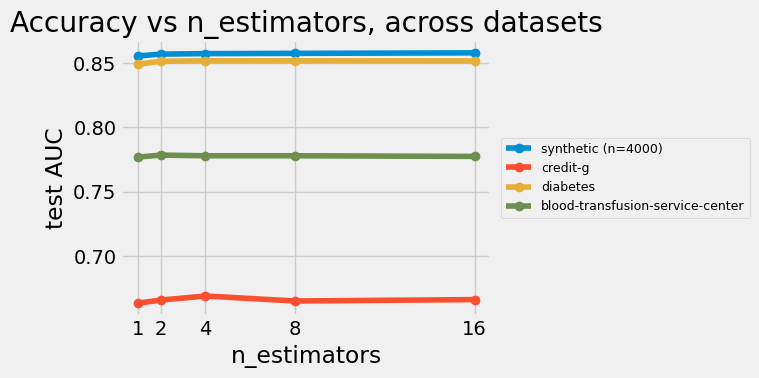

In [2]:
# Accuracy saturates with n_estimators, but is that a quirk of one synthetic task? Sweep several
# datasets of different size and difficulty. We warm up once per dataset so timing is not measured here.
datasets = {"synthetic (n=4000)": make_data(n=4000, seed=0)}
for name in ["credit-g", "diabetes", "blood-transfusion-service-center"]:
    datasets[name] = load_openml_binary(name)

estimator_counts = [1, 2, 4, 8, 16]
rows = []
for dataset_name, (X, y) in datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=0, stratify=y)
    TabPFNClassifier(n_estimators=1, random_state=0).fit(X_train, y_train).predict_proba(X_test)  # warm up
    record = {"dataset": dataset_name}
    for n_estimators in estimator_counts:
        model = TabPFNClassifier(n_estimators=n_estimators, random_state=0).fit(X_train, y_train)
        record[f"n={n_estimators}"] = round(roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]), 4)
    rows.append(record)
auc_table = pd.DataFrame(rows).set_index("dataset")
print(auc_table.to_string())

fig, ax = plt.subplots(figsize=(7.5, 4))
for dataset_name in auc_table.index:
    ax.plot(estimator_counts, auc_table.loc[dataset_name].values, marker="o", label=dataset_name)
ax.set_xlabel("n_estimators"); ax.set_ylabel("test AUC"); ax.set_xticks(estimator_counts)
ax.set_title("Accuracy vs n_estimators, across datasets")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=9)
fig.tight_layout(); plt.show()

In [3]:
# The cost side: time grows with the estimator count, each one is another pass over the data.
X, y = make_data(n=4000, seed=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=0, stratify=y)
TabPFNClassifier(n_estimators=1, random_state=0).fit(X_train, y_train).predict_proba(X_test)  # warm up
for n_estimators in [1, 4, 16]:
    start = time.perf_counter()
    TabPFNClassifier(n_estimators=n_estimators, random_state=0).fit(X_train, y_train).predict_proba(X_test)
    print(f"n_estimators={n_estimators:2d}: {time.perf_counter() - start:.2f}s")

n_estimators= 1: 0.80s


n_estimators= 4: 1.50s


n_estimators=16: 3.42s


The same shape shows up on every dataset: accuracy is essentially settled by two to four estimators,
and the climb from there to sixteen is a few thousandths at most. The exact saturation point and the
size of the gain vary (a small, noisy dataset like credit-g wobbles more than it climbs), so this is a
general tendency rather than a law, but the practical rule is solid: the default of 8 sits comfortably
past saturation on all four, and you can drop to 2 to 4 for speed with little to lose. Time, meanwhile,
grows with the count, so the extra estimators buy a diminishing accuracy gain at a roughly linear cost.

## What the calibration knobs do, and when you need them

These two knobs matter the moment you stop ranking and start *deciding*. Most production uses of a
classifier threshold its probability to take an action: call this customer, review this claim, hold
this transaction. A cutoff like 0.5 only means "more likely than not" when the probabilities are
*calibrated*. `balance_probabilities` and `softmax_temperature` reshape the probability distribution
without touching the ranking, both are monotone transforms, so AUC and AUPRC are unchanged by
construction, which means what they really move is where your threshold bites. We show this first on
the shape of the output, then on a real imbalanced decision.

calibration error (ECE):  default 0.021   balanced 0.311


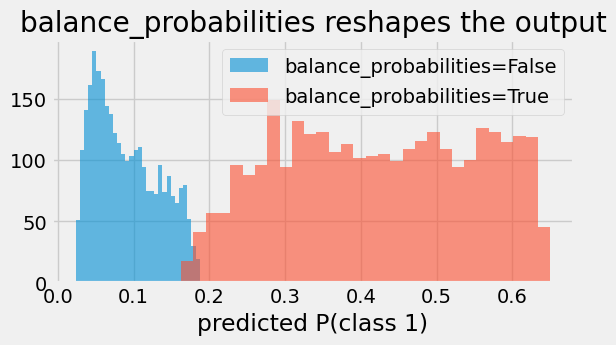

In [4]:
# balance_probabilities on a HARD, imbalanced task (uncertain model, so the shift is visible).
rng = np.random.RandomState(1)
m = 6000
Xb = rng.randn(m, 4)
logit = 0.5 * Xb[:, 0] - 2.2                                 # weak signal + low base rate (uncertain, ~11% positive)
yb = (rng.rand(m) < 1 / (1 + np.exp(-logit))).astype(int)
Xtr, Xte = pd.DataFrame(Xb[:m // 2]), pd.DataFrame(Xb[m // 2:]); ytr, yte = yb[:m // 2], yb[m // 2:]

p_off = TabPFNClassifier(random_state=0).fit(Xtr, ytr).predict_proba(Xte)[:, 1]
p_on  = TabPFNClassifier(balance_probabilities=True, random_state=0).fit(Xtr, ytr).predict_proba(Xte)[:, 1]

print(f"calibration error (ECE):  default {expected_calibration_error(yte, p_off):.3f}"
      f"   balanced {expected_calibration_error(yte, p_on):.3f}")

plt.figure(figsize=(6, 3))
plt.hist(p_off, bins=30, alpha=0.6, label="balance_probabilities=False")
plt.hist(p_on,  bins=30, alpha=0.6, label="balance_probabilities=True")
plt.legend(); plt.xlabel("predicted P(class 1)"); plt.title("balance_probabilities reshapes the output")
plt.show()

temperature 0.5: calibration error (ECE) 0.110


temperature 0.9: calibration error (ECE) 0.029


temperature 2.0: calibration error (ECE) 0.056


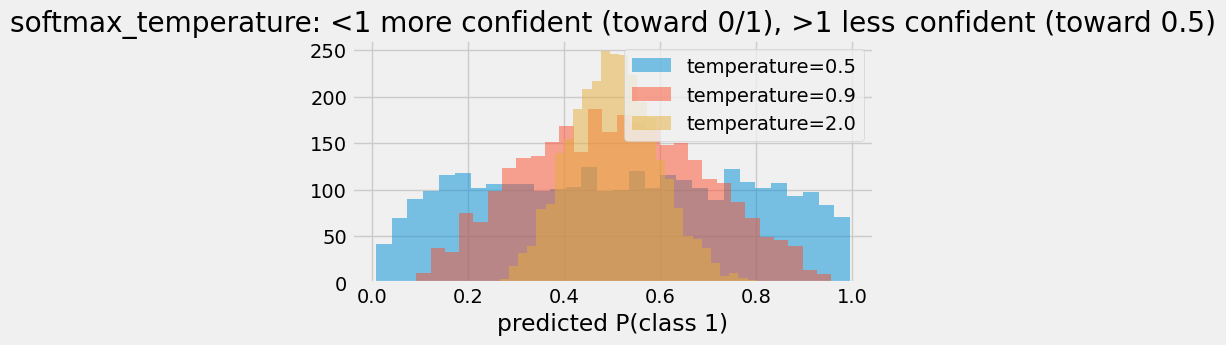

In [5]:
# softmax_temperature on a HARD, balanced task (uncertain model, so sharpen/soften shows).
rng = np.random.RandomState(2)
m = 6000
Xt = rng.randn(m, 6)
logit = 0.6 * Xt[:, 0] + 0.4 * Xt[:, 1]
yt = (rng.rand(m) < 1 / (1 + np.exp(-logit))).astype(int)
Xtr, Xte = pd.DataFrame(Xt[:m // 2]), pd.DataFrame(Xt[m // 2:]); ytr, yte = yt[:m // 2], yt[m // 2:]

plt.figure(figsize=(6, 3))
for t in [0.5, 0.9, 2.0]:
    p = TabPFNClassifier(softmax_temperature=t, random_state=0).fit(Xtr, ytr).predict_proba(Xte)[:, 1]
    print(f"temperature {t}: calibration error (ECE) {expected_calibration_error(yte, p):.3f}")
    plt.hist(p, bins=30, alpha=0.5, label=f"temperature={t}")
plt.legend(); plt.xlabel("predicted P(class 1)"); plt.title("softmax_temperature: <1 more confident (toward 0/1), >1 less confident (toward 0.5)")
plt.show()

In [6]:
# A real threshold decision: a marketing campaign on imbalanced data (~12% subscribe). We threshold
# the probability at 0.5 to decide whom to call, and watch what the knob does to that decision.
X, y = load_openml_binary("bank-marketing", n_cap=6000)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=0, stratify=y)
print(f"positive (subscribe) rate: {y.mean():.3f}\n")

for label, settings in [("default", {}), ("balance_probabilities=True", {"balance_probabilities": True})]:
    p = TabPFNClassifier(random_state=0, **settings).fit(X_train, y_train).predict_proba(X_test)[:, 1]
    flagged = p >= 0.5
    print(f"{label}:")
    print(f"  AUC {roc_auc_score(y_test, p):.3f} (ranking)   "
          f"ECE {expected_calibration_error(y_test, p):.3f} (calibration)   mean prob {p.mean():.3f}")
    print(f"  at threshold 0.5 -> call {flagged.mean():.1%} of customers, "
          f"precision {precision_score(y_test, flagged, zero_division=0):.2f}, "
          f"recall {recall_score(y_test, flagged):.2f}\n")

positive (subscribe) rate: 0.117



default:
  AUC 0.883 (ranking)   ECE 0.010 (calibration)   mean prob 0.110
  at threshold 0.5 -> call 5.4% of customers, precision 0.62, recall 0.29



balance_probabilities=True:
  AUC 0.883 (ranking)   ECE 0.196 (calibration)   mean prob 0.313
  at threshold 0.5 -> call 28.1% of customers, precision 0.35, recall 0.83



The histograms and the campaign tell one story. The AUC is identical with and without the knob, the
ranking does not move, so neither knob can "improve" a ranking metric. What moves is the *operating
point*. The default model is well-calibrated (ECE around 0.01, mean probability near the 12% base
rate), so a 0.5 cutoff calls about 5% of customers at decent precision. `balance_probabilities` lifts
the whole distribution toward the minority class (mean probability jumps, ECE blows up past 0.1), so
the same 0.5 cutoff now calls roughly five times as many people: recall soars, precision falls. That is
the knob's actual job, shifting where a fixed threshold lands.

`softmax_temperature` is the same lesson in the other direction: below 1 it sharpens probabilities
toward 0 and 1, above 1 it softens them toward 0.5, and the default 0.9 sits near the best-calibrated
point (the printed ECE is lowest there, about 0.03 against 0.11 at 0.5 and 0.06 at 2.0). Reach for
either knob only when a fixed cutoff or a calibrated probability is what you actually need, never to
improve AUC. (A gradient-boosting model's `scale_pos_weight` is what people often expect to help
ranking; this is not that.)

## Speed and memory: fit_mode and the shape of in-context learning

TabPFN has no training loop, so its `.fit()` does something unusual: it stores your training data as
the *context* the forward pass will condition on. `fit_mode` decides how much of that conditioning is
precomputed and cached, which is the clearest window into how in-context learning actually runs. The
preprocessing it refers to is the same ensemble we keep meeting: TabPFN builds one differently
preprocessed copy of the data per estimator.

- `low_memory` caches nothing. Every `.predict()` re-runs the full preprocessing, fitting the
  preprocessors on the training data and transforming both train and test, once per estimator, and
  then the forward pass. Smallest memory footprint, slowest repeated prediction.
- `fit_preprocessors` (the default) fits the preprocessors once at `.fit()` and caches the transformed
  *training* data (in CPU RAM). Each `.predict()` then only transforms the test rows and runs the
  forward pass, no re-fitting of the preprocessing.
- `fit_with_cache` does all of that and, in addition, pushes the preprocessed training context through
  the transformer at `.fit()` to compute and store its **key-value cache**, one per estimator. In a
  transformer the training rows become the keys and values that test rows attend to; caching them means
  a later `.predict()` skips recomputing the whole training context and only passes the test queries
  through attention. Fastest repeated prediction, at the highest memory cost (the caches sit in CPU RAM).

So the answer to "what gets recomputed" climbs in three steps: `low_memory` redoes the preprocessing
every time, `fit_preprocessors` keeps the preprocessed training data, and `fit_with_cache` also keeps
the attention representation of that data. None of the three changes a single prediction. The next cell
times all three on the same data.

In [7]:
X, y = make_data(n=6000, seed=1)
half = len(y) // 2
X_train, X_test, y_train, y_test = X.iloc[:half], X.iloc[half:], y[:half], y[half:]

rows = []
for fit_mode in ["low_memory", "fit_preprocessors", "fit_with_cache"]:
    start = time.perf_counter()
    model = TabPFNClassifier(fit_mode=fit_mode, random_state=0).fit(X_train, y_train)
    fit_seconds = time.perf_counter() - start
    start = time.perf_counter()
    for _ in range(3):                       # repeated predictions on the same training data
        model.predict_proba(X_test)
    predict_seconds = (time.perf_counter() - start) / 3
    rows.append({"fit_mode": fit_mode, "fit_seconds": round(fit_seconds, 2),
                 "predict_seconds (avg of 3)": round(predict_seconds, 2)})
print(pd.DataFrame(rows).to_string(index=False))

         fit_mode  fit_seconds  predict_seconds (avg of 3)
       low_memory         0.63                        2.11
fit_preprocessors         0.63                        2.09
   fit_with_cache         1.87                        0.96


The shape is the point. `fit_with_cache` pays more at `.fit()`, where it builds the key-value cache,
and then predicts roughly twice as fast, because the expensive context conditioning is already done.
`low_memory` and `fit_preprocessors` fit cheaply and pay it back at predict time. So if you score the
same training data many times, `fit_with_cache` wins; if memory is tight or you predict only once,
stay with the default. Again, none of this moves a prediction, only the clock and the memory bill.

Two more performance knobs in the same spirit, neither of which touches the output:

- `memory_saving_mode` (`"auto"` by default, or `True`/`False`) batches some internal computations to
  avoid out-of-memory errors, and can even speed things up by easing memory pressure. Leave it on
  `"auto"`, force a value only when hand-tuning a tight GPU: `TabPFNClassifier(memory_saving_mode=True)`.
- `inference_precision` (`"auto"`, `"autocast"`, or a `torch.dtype`) uses mixed precision for speed by
  default; pinning a dtype trades speed for reproducibility:
  `TabPFNClassifier(inference_precision=torch.float32)` for the most repeatable run.

## Inspect what TabPFN decided

You do not tune the preprocessing, but you can read it. After a fit, `inference_config_` holds the
resolved limits and thresholds, and `inferred_feature_schema_` shows the modality TabPFN assigned to
each column (which is what `categorical_features_indices` would override).

In [8]:
Xq = pd.DataFrame(np.random.RandomState(0).randn(200, 5), columns=["a", "b", "c", "d", "e"])
yq = (Xq["a"] > 0).astype(int)
model = TabPFNClassifier(random_state=0).fit(Xq, yq)

print("Envelope (hard ceilings):")
for field in ["MAX_NUMBER_OF_SAMPLES", "MAX_NUMBER_OF_FEATURES", "MAX_NUMBER_OF_CLASSES"]:
    print(f"  {field} = {getattr(model.inference_config_, field)}")

print("\nPreprocessing thresholds:")
for field in ["MAX_UNIQUE_FOR_CATEGORICAL_FEATURES", "MIN_UNIQUE_FOR_NUMERICAL_FEATURES",
              "MIN_NUMBER_SAMPLES_FOR_CATEGORICAL_INFERENCE", "OUTLIER_REMOVAL_STD"]:
    print(f"  {field} = {getattr(model.inference_config_, field)}")

print("\nInferred column modality (first five columns):")
for feature in model.inferred_feature_schema_.features[:5]:
    print(f"  {feature.name}: {feature.modality.value}")

Envelope (hard ceilings):
  MAX_NUMBER_OF_SAMPLES = 1000000
  MAX_NUMBER_OF_FEATURES = 2000
  MAX_NUMBER_OF_CLASSES = 160

Preprocessing thresholds:
  MAX_UNIQUE_FOR_CATEGORICAL_FEATURES = 30
  MIN_UNIQUE_FOR_NUMERICAL_FEATURES = 4
  MIN_NUMBER_SAMPLES_FOR_CATEGORICAL_INFERENCE = 100
  OUTLIER_REMOVAL_STD = auto

Inferred column modality (first five columns):
  a: numerical
  b: numerical
  c: numerical
  d: numerical
  e: numerical


The **envelope** is the hard ceiling the checkpoint was built for (a million rows, two thousand
features, a hundred and sixty classes). Separately, `ignore_pretraining_limits` guards a softer
*recommended* operating range, and pushing well past it is where accuracy starts to slip. The
**thresholds** are the rules behind the auto-detection: a string column with 30 or fewer distinct
values is treated as categorical, a numeric column needs at least 4 distinct values to stay numeric,
and category inference needs at least 100 rows. Those are the knobs the scaling and categorical
chapters open up through `inference_config`.

## Pointing at the model: model_path and inference_config

`model_path` selects the checkpoint. `"auto"` (the default) downloads the v3 default classifier on
first use and caches it; you can redirect the cache with the `TABPFN_MODEL_CACHE_DIR` environment
variable. The envelope and thresholds printed above are read straight off that v3 checkpoint.

The package ships more than one checkpoint, and several map onto problems we meet elsewhere in the
series: a v2.5 family with large-features and large-samples variants for wide or tall data, and v3
variants tuned for different numeric priors (a low-skew and a quantiles checkpoint that connect to the
skewed-variables chapter), small samples, and so on. You point at one with a filesystem path to a
`.ckpt`, for example `TabPFNClassifier(model_path="path/to/checkpoint.ckpt")`; the repository README
lists the exact identifiers. For almost every use the `"auto"` v3 default is the right answer.

`inference_config` is the door to the internal preprocessing. The cell below prints the *default*
preprocessing pipeline, then replaces it with a single transform, which is how the scaling and
categorical chapters reach inside the model.

In [9]:
from tabpfn.preprocessing import PreprocessorConfig

sample = pd.DataFrame(np.random.RandomState(0).randn(200, 5), columns=list("abcde"))
sample_label = (sample["a"] > 0).astype(int)

default_model = TabPFNClassifier(n_estimators=2, random_state=0).fit(sample, sample_label)
print("Default preprocessing pipeline (TabPFN draws from these across estimators):")
for transform in default_model.inference_config_.PREPROCESS_TRANSFORMS:
    print("  ", transform)

custom_model = TabPFNClassifier(
    n_estimators=2, random_state=0,
    inference_config={"PREPROCESS_TRANSFORMS": [PreprocessorConfig(name="quantile_uni_coarse")]},
).fit(sample, sample_label)
print("\nOverridden to a single quantile transform:")
for transform in custom_model.inference_config_.PREPROCESS_TRANSFORMS:
    print("  ", transform)

Default preprocessing pipeline (TabPFN draws from these across estimators):
   squashing_scaler_default_cat:ordinal_very_common_categories_shuffled_max_feats_per_est_200_global_transformer_svd_quarter_components
   quantile_uni_cat:numeric_max_feats_per_est_200



Overridden to a single quantile transform:
   quantile_uni_coarse_cat:none_max_feats_per_est_500


The default pipeline is itself an ensemble: TabPFN applies a different preprocessing to the data for
each estimator (a squashing scaler here, a quantile transform there), which is part of why more
estimators help, every member sees the data through a slightly different lens. `inference_config` lets
you replace that pipeline outright, as above, or change a single setting like the outlier-clip width or
the categorical-detection thresholds. It validates your keys, an unknown one raises rather than failing
silently. For most work you never touch it; it is the door the scaling and categorical chapters open.

## Every other knob, in one place

For completeness, the settings that did not need their own section, each as a one-line example:

- `TabPFNClassifier(average_before_softmax=True)`: average the estimators' logits before the softmax
  instead of their probabilities (only matters with `n_estimators > 1`, can help calibration and
  many-class problems).
- `TabPFNClassifier(n_preprocessing_jobs=1)`: CPU worker processes for preprocessing; `1` (the
  default) is usually best, raise it only with many cores and `n_estimators > 1`.
- `TabPFNClassifier(device="cuda")`: where inference runs; `"auto"` picks the GPU if one is present.
- `TabPFNClassifier(random_state=0)`: the seed; TabPFN fixes it to 0 by default, unlike most
  scikit-learn estimators.
- `TabPFNClassifier(show_progress_bar=True)`: a progress bar during inference.
- `TabPFNClassifier(eval_metric="roc_auc", tuning_config=...)`: opt into a post-hoc search that
  calibrates probabilities and tunes the decision threshold for the chosen metric.
- `TabPFNClassifier(differentiable_input=True)`: make the preprocessing end-to-end differentiable,
  for explainability and prompt-tuning work.

## Takeaways

- TabPFN is pretrained, so there is no hyperparameter *search*. You configure inference, and the
  defaults are strong.
- **`n_estimators`** trades compute for a small, saturating accuracy gain; the default is a sensible
  middle.
- **`balance_probabilities`** and **`softmax_temperature`** never change the ranking (a monotone
  transform cannot); they shift the operating point and the calibration. Use them only if you
  threshold at a fixed cutoff or need calibrated probabilities.
- **`categorical_features_indices`** and **`ignore_pretraining_limits`** tell TabPFN the truth about
  your data: which columns are categorical, and whether you are past its recommended size.
- **`inference_config`** is the door to the internal preprocessing (scaling, outlier clipping,
  categorical thresholds), and the envelope and thresholds above are read straight off it.

The shift from gradient boosting: you are not tuning a model, you are configuring a fixed one, and
most of the time the defaults are the right answer.